<a href="https://colab.research.google.com/github/Monika-802/IN126018002_-Gen-Ai/blob/main/NLP_Task_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving imdb_dataset.csv to imdb_dataset (3).csv


In [ ]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

data = pd.read_csv("imdb_dataset.csv")
data = data.dropna(subset=["review", "sentiment"])
data["review"] = data["review"].apply(clean_text)
data["label"] = data["sentiment"].map({"negative": 0, "positive": 1})
data = data[["review", "label"]]

print(data.head())
print("\nLabel Distribution:\n", data["label"].value_counts())
print("\nData Info:")
print(data.info())

                                           review  label
0  This movie was fantastic with brilliant acting      1
1         Absolutely terrible film, waste of time      0
2        I loved the storyline and the characters      1
3                           Worst movie ever made      0
4               An excellent cinematic experience      1

Label Distribution:
 label
1    5
0    5
Name: count, dtype: int64

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  10 non-null     object
 1   label   10 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 292.0+ bytes
None


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
from sklearn.model_selection import train_test_split

train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    data["review"], data["label"], test_size=0.3, random_state=42)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=42)

for name, dataset in zip(["Train", "Val", "Test"], [train_texts, val_texts, test_texts]):
    print(f"{name} set: {len(dataset)} rows")

print("\nSample Training Data:")
print(train_texts.head())

Train set: 7 rows
Val set: 1 rows
Test set: 2 rows

Sample Training Data:
0    This movie was fantastic with brilliant acting
7                         Not worth watching at all
2          I loved the storyline and the characters
9                       Poor script and weak acting
4                 An excellent cinematic experience
Name: review, dtype: object


In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize(texts):
    return tokenizer(list(texts), padding=True, truncation=True, max_length=256, return_tensors="pt")

train_encodings = tokenize(train_texts)
val_encodings = tokenize(val_texts)
test_encodings = tokenize(test_texts)

print("Tokenization Complete.")

print("\nHuman-readable tokens for first review:")
tokens = tokenizer.convert_ids_to_tokens(train_encodings['input_ids'][0])
print(tokens[:20])

Tokenization Complete.

Human-readable tokens for first review:
['[CLS]', 'this', 'movie', 'was', 'fantastic', 'with', 'brilliant', 'acting', '[SEP]']


In [ ]:
import torch
from transformers import AutoModelForSequenceClassification

class TextDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.tolist()

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = TextDataset(train_encodings, train_labels)
val_dataset = TextDataset(val_encodings, val_labels)

model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

print("Model is Loaded:")
print(f"Model type: {type(model)}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model is Loaded:
Model type: <class 'transformers.models.bert.modeling_bert.BertForSequenceClassification'>


In [ ]:
!pip install seaborn

Saving imdb_dataset.csv to imdb_dataset (4).csv


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packag

Epoch 1 | Loss: 0.6932 | Val Acc: 0.0000 | Val F1: 0.0000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 2 | Loss: 0.6730 | Val Acc: 0.0000 | Val F1: 0.0000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 3 | Loss: 0.6331 | Val Acc: 0.0000 | Val F1: 0.0000

Final Test Results
Accuracy: 0.0000
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


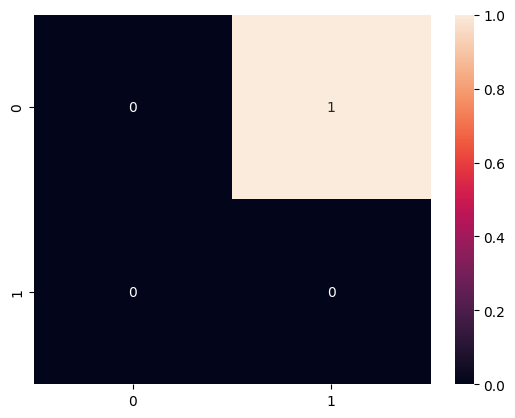

In [ ]:
import torch
import pandas as pd
from torch.utils.data import DataLoader, Dataset
from torch.optim import AdamW
from transformers import BertTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

uploaded = files.upload()
file_name = list(uploaded.keys())[0]


df = pd.read_csv(file_name)
df = df[['review', 'sentiment']].dropna()
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

train_texts, temp_texts, train_labels, temp_labels = train_test_split(df['review'], df['sentiment'], test_size=0.2, random_state=42)
val_texts, test_texts, val_labels, test_labels = train_test_split(temp_texts, temp_labels, test_size=0.5, random_state=42)

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

class IMDBDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts.tolist()
        self.labels = labels.tolist()

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = tokenizer(
            self.texts[idx],
            padding='max_length',
            truncation=True,
            max_length=128,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = IMDBDataset(train_texts, train_labels)
val_dataset = IMDBDataset(val_texts, val_labels)
test_dataset = IMDBDataset(test_texts, test_labels)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=16)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)
model.to(device)

optimizer = AdamW(model.parameters(), lr=2e-5)
epochs = 3
total_steps = len(train_loader) * epochs
scheduler = get_linear_schedule_with_warmup(optimizer, 0, total_steps)

def train_epoch(model, loader):
    model.train()
    total_loss = 0
    for batch in loader:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader):
    model.eval()
    preds, true_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            true_labels.extend(labels.cpu().numpy())
    acc = accuracy_score(true_labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(true_labels, preds, average='binary')
    cm = confusion_matrix(true_labels, preds)
    return acc, precision, recall, f1, cm

for epoch in range(epochs):
    loss = train_epoch(model, train_loader)
    val_acc, _, _, val_f1, _ = evaluate(model, val_loader)
    print(f"Epoch {epoch+1} | Loss: {loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

acc, prec, rec, f1, cm = evaluate(model, test_loader)

print("\nFinal Test Results")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.show()